In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, stats

In [21]:
def phase_difference(x, y):
    # Calculate the analytic signal using the Hilbert transform
    analytic_x = signal.hilbert(x)
    analytic_y = signal.hilbert(y)
    
    # Calculate the instantaneous phase difference
    phase_diff = np.angle(analytic_y) - np.angle(analytic_x)
    
    # Wrap to [-pi, pi]
    return np.angle(np.exp(1j * phase_diff))


def rayleigh_stats(phase):
    # Calculate mean vector
    mean_x = np.mean(np.cos(phase))
    mean_y = np.mean(np.sin(phase))
    
    # Calculate mean resultant length and angle
    R = np.sqrt(mean_x**2 + mean_y**2)
    theta_mean = np.arctan2(mean_y, mean_x)
    
    return R, theta_mean


def plot_rayleigh(phase, R, theta_mean, save: bool = False, filepath: str = None):
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
    
    # Plot data points (all with radius 1)
    ax.scatter(phase, np.ones_like(phase), alpha=0.5)
    
    # Plot mean vector
    ax.arrow(0, 0, theta_mean, R, alpha=0.8, width=0.02,
             edgecolor='red', facecolor='red', lw=2, zorder=5)
    
    ax.set_ylim(0, 1.1)  # Set radial limit
    ax.set_rticks([0.5, 1])  # Add some radial ticks
    ax.set_rlabel_position(-22.5)  # Move radial labels away from plotted line
    ax.grid(True)
    
    ax.set_title(f"R: {R:.4f}, Mean Phase Diff (degrees): {np.degrees(theta_mean):.2f}")
    plt.tight_layout()

    if save:
        plt.savefig(f"{filepath}_rayleigh.eps", format='eps')
    
    plt.show()


def rayleigh_test(phase_diff):
    n = len(phase_diff)
    R, _ = rayleigh_stats(phase_diff)
    
    # Calculate the test statistic
    Z = n * R**2
    
    # Calculate the p-value
    p_value = np.exp(-(Z))
    
    return Z, p_value


def rayleigh_pipe(x, y, plot = False, save: bool = False, filepath: str = None):
    t = np.arange(0, x.shape[0])

    phase_diff = phase_difference(x, y)

    # Calculate Rayleigh statistics
    R, theta_mean = rayleigh_stats(phase_diff)

    if plot:
        # Plot the results
        plot_rayleigh(phase_diff, R, theta_mean, save, filepath)

        # Plot the original time series
        plt.figure(figsize=(10, 6))
        plt.plot(t, x, label='Terminal')
        plt.plot(t, y, label='Nac Cluster')
        plt.axvline(x=100, color='r', linestyle='--')

        ax = plt.gca()
        def format_func(value, tick_number):
            return int(value/10) - 10

        ax.xaxis.set_major_formatter(plt.FuncFormatter(format_func))

        plt.xlabel('Time (in s)')
        plt.ylabel('Amplitude')
        plt.title('Original Time Series')
        plt.legend()
        plt.savefig(f"{filepath}_timeseries.eps", format='eps')
        plt.show()
        
    return R, theta_mean

In [33]:
def circular_mean(angles):
    return np.angle(np.mean(np.exp(1j * angles)))

def plot_rayleigh2(mean_thetas: np.ndarray, mean_rs: np.ndarray):
    R = mean_rs.mean()
    theta_mean = circular_mean(mean_thetas)

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))
    
    # Plot data points (all with radius 1)
    ax.scatter(mean_thetas, np.ones_like(mean_thetas), alpha=0.5)
    
    # Plot mean vector
    ax.arrow(0, 0, theta_mean, R, alpha=0.8, width=0.02,
             edgecolor='red', facecolor='red', lw=2, zorder=5)
    
    ax.set_ylim(0, 1.1)  # Set radial limit
    ax.set_rticks([0.5, 1])  # Add some radial ticks
    ax.set_rlabel_position(-22.5)  # Move radial labels away from plotted line
    ax.grid(True)
    
    ax.set_title(f"R: {R:.4f}, Mean Phase Diff (degrees): {np.degrees(theta_mean):.2f}")
    plt.tight_layout()
    
    plt.show()

In [23]:
traces_source = r"/Users/hades/Desktop/Bruchas Lab/Encoder_Decoder/DJM_binary_classification/Relate_Terminal_to_NAc/signal_data/NAc_Cluster_Traces"
terminal_source = r"/Users/hades/Desktop/Bruchas Lab/Encoder_Decoder/DJM_binary_classification/Relate_Terminal_to_NAc/signal_data/Terminal_signal.npy"

terminal = np.load(terminal_source)

files = sorted([f for f in os.listdir(traces_source) if f.endswith(".npy")])
full_paths = [os.path.join(traces_source, f) for f in files]
cluster_traces = [np.load(f) for f in full_paths]

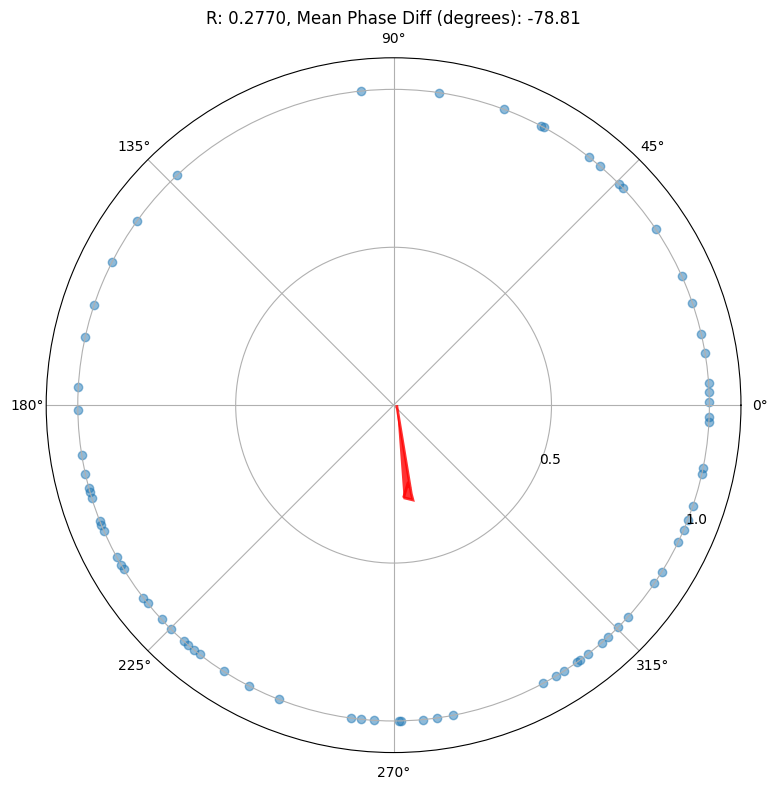

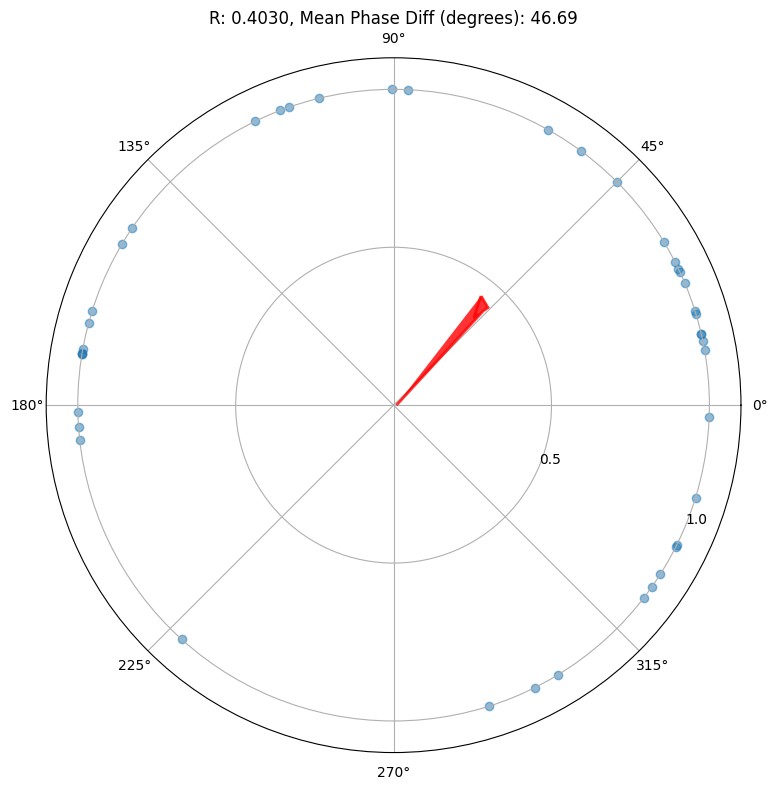

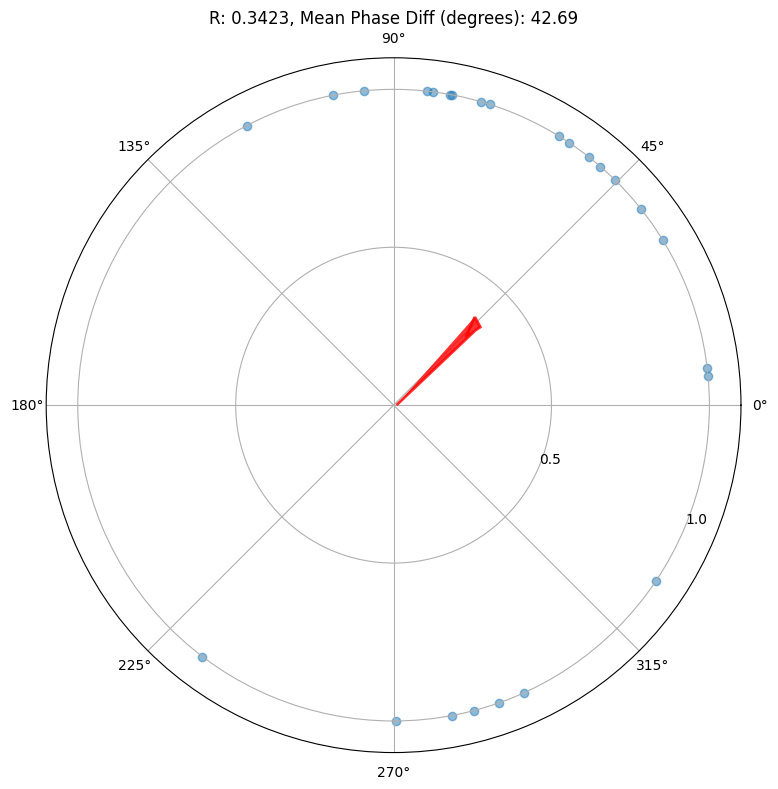

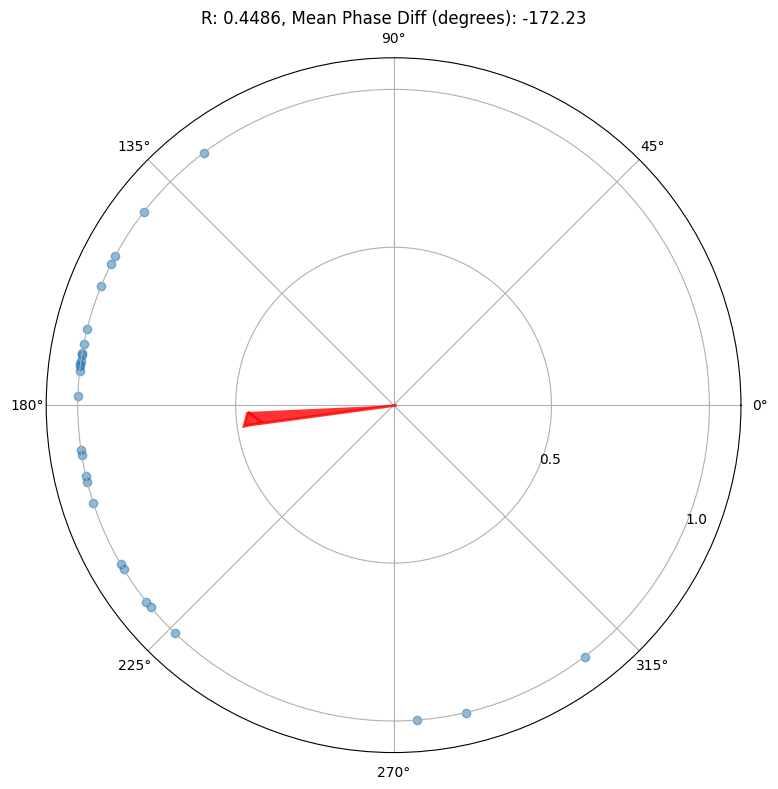

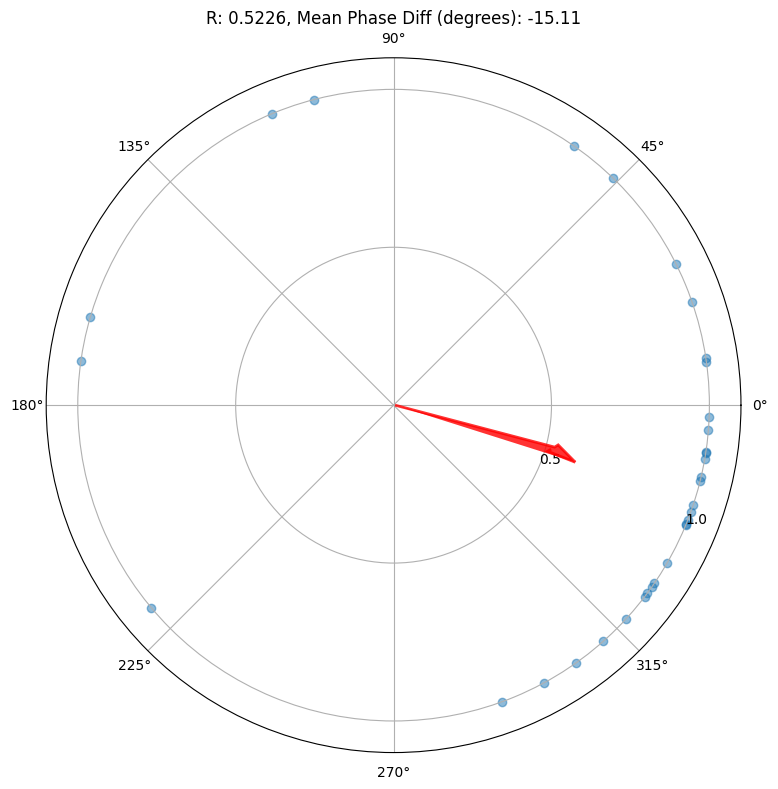

In [34]:
cluster_data = dict()

for i, cluster in enumerate(cluster_traces, start=1):
    Rs = []
    phases = []

    for trace in cluster:
        trace = trace[1:]
        R, phase = rayleigh_pipe(terminal, trace)
        Rs.append(R)
        phases.append(float(phase))

    Rs_np = np.array(Rs)
    phases_np = np.array(phases)

    plot_rayleigh2(phases_np, Rs_np)

    cluster_data[i] = (Rs_np, phases_np)

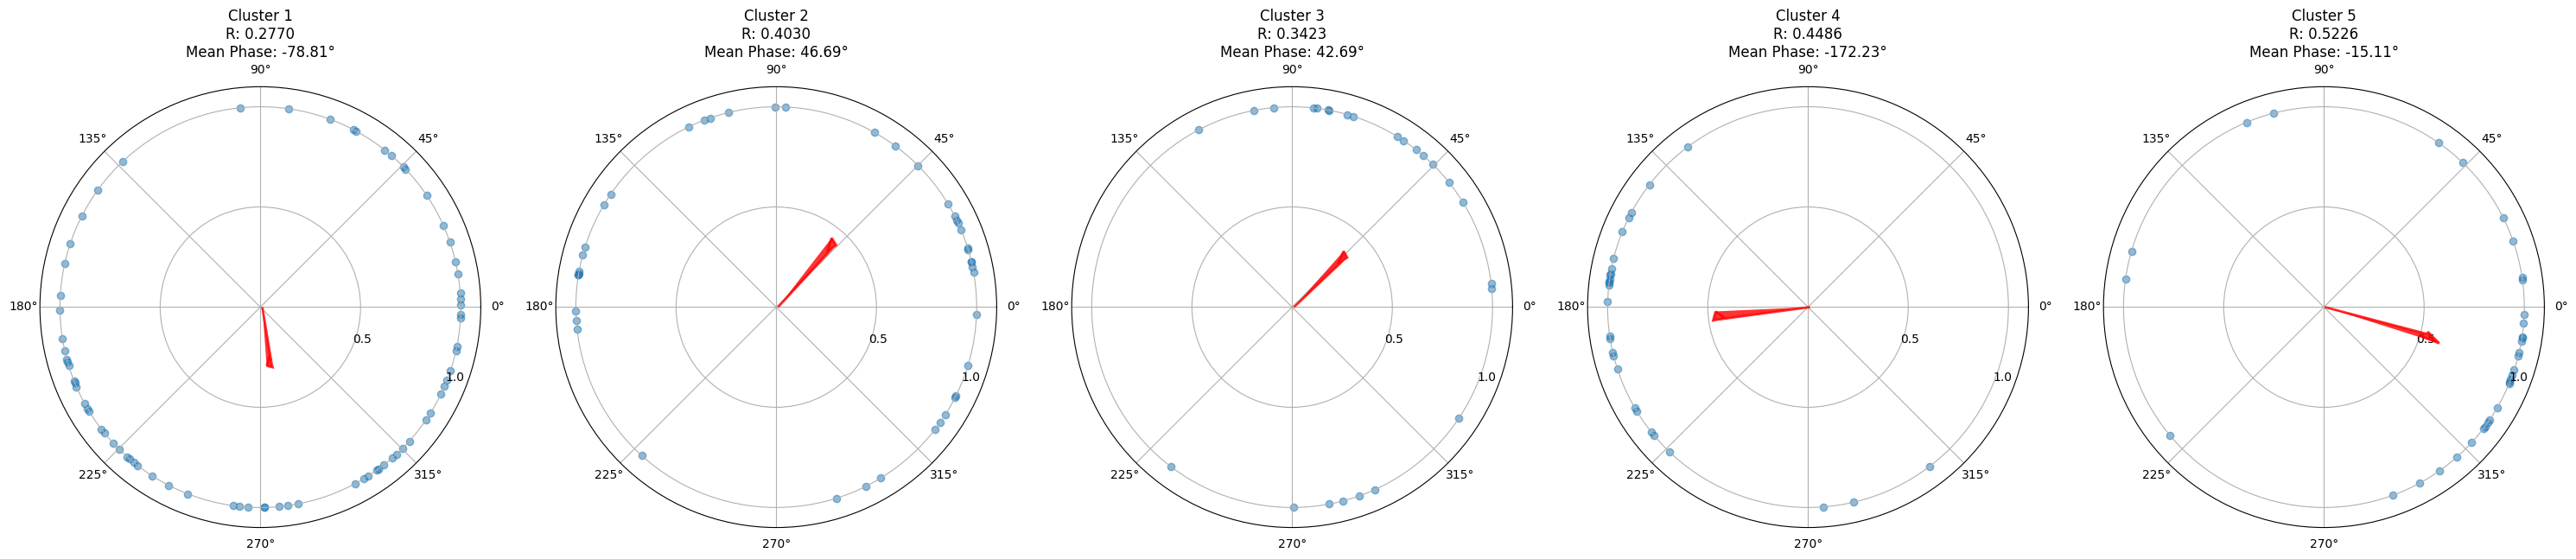

In [37]:
import matplotlib.pyplot as plt
import numpy as np

def circular_mean(angles):
    return np.angle(np.mean(np.exp(1j * angles)))

def plot_rayleigh2(ax, mean_thetas: np.ndarray, mean_rs: np.ndarray, cluster_num: int):
    R = mean_rs.mean()
    theta_mean = circular_mean(mean_thetas)

    # Plot data points (all with radius 1)
    ax.scatter(mean_thetas, np.ones_like(mean_thetas), alpha=0.5)
    
    # Plot mean vector
    ax.arrow(0, 0, theta_mean, R, alpha=0.8, width=0.02,
             edgecolor='red', facecolor='red', lw=2, zorder=5)
    
    ax.set_ylim(0, 1.1)  # Set radial limit
    ax.set_rticks([0.5, 1])  # Add some radial ticks
    ax.set_rlabel_position(-22.5)  # Move radial labels away from plotted line
    ax.grid(True)
    
    ax.set_title(f"Cluster {cluster_num}\nR: {R:.4f}\nMean Phase: {np.degrees(theta_mean):.2f}°")

# Assuming cluster_traces and terminal are defined earlier in your code

cluster_data = dict()

# Calculate the number of clusters
n_clusters = len(cluster_traces)

# Create the figure and axes
fig, axes = plt.subplots(1, n_clusters, figsize=(6*n_clusters, 6), 
                         subplot_kw=dict(projection='polar'))

# Ensure axes is always an array
if n_clusters == 1:
    axes = [axes]

for i, cluster in enumerate(cluster_traces, start=1):
    Rs = []
    phases = []

    for trace in cluster:
        trace = trace[1:]
        R, phase = rayleigh_pipe(terminal, trace)
        Rs.append(R)
        phases.append(float(phase))

    Rs_np = np.array(Rs)
    phases_np = np.array(phases)

    # Plot in the corresponding subplot
    plot_rayleigh2(axes[i-1], phases_np, Rs_np, i)

    cluster_data[i] = (Rs_np, phases_np)

plt.tight_layout()
plt.show()

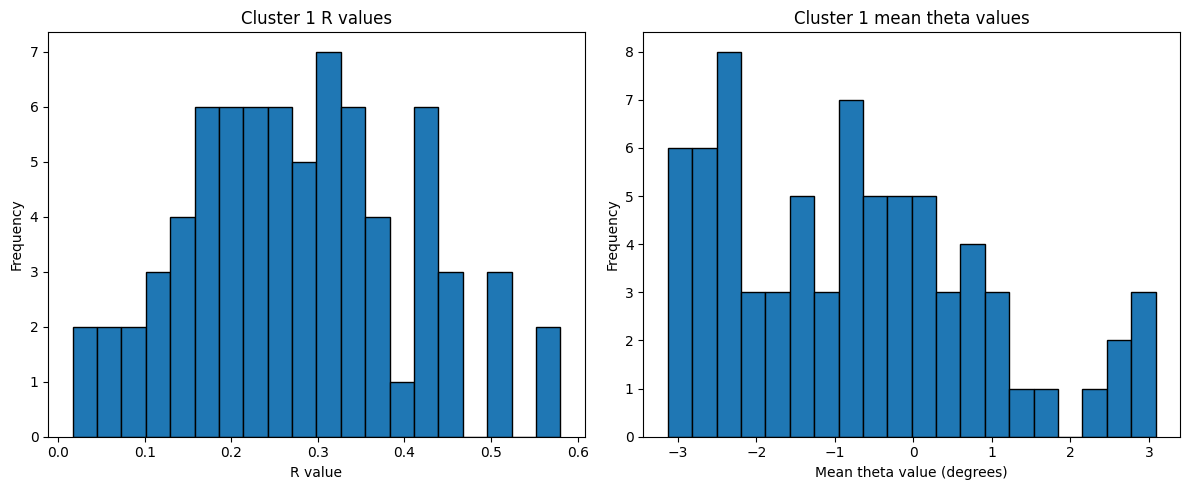

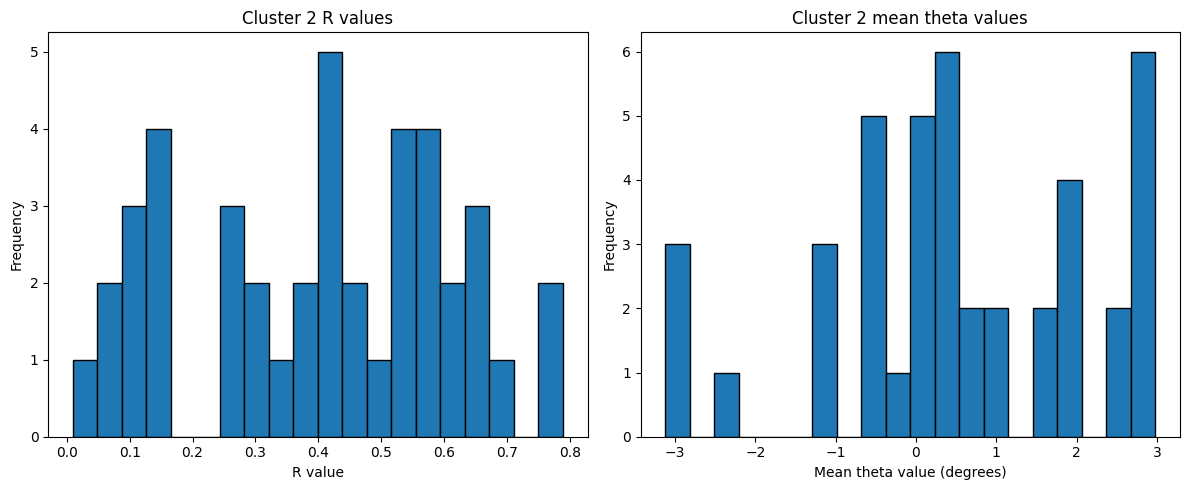

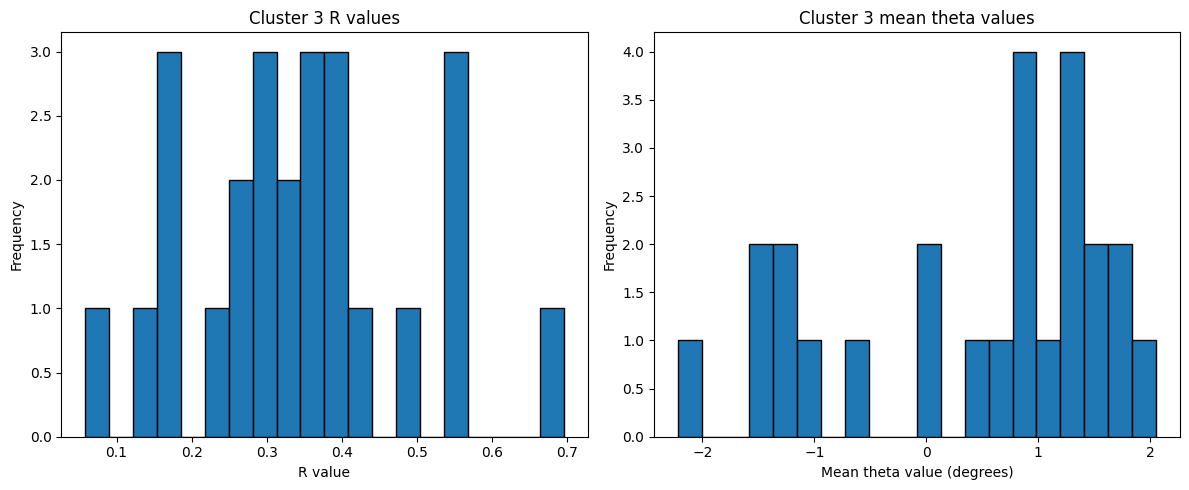

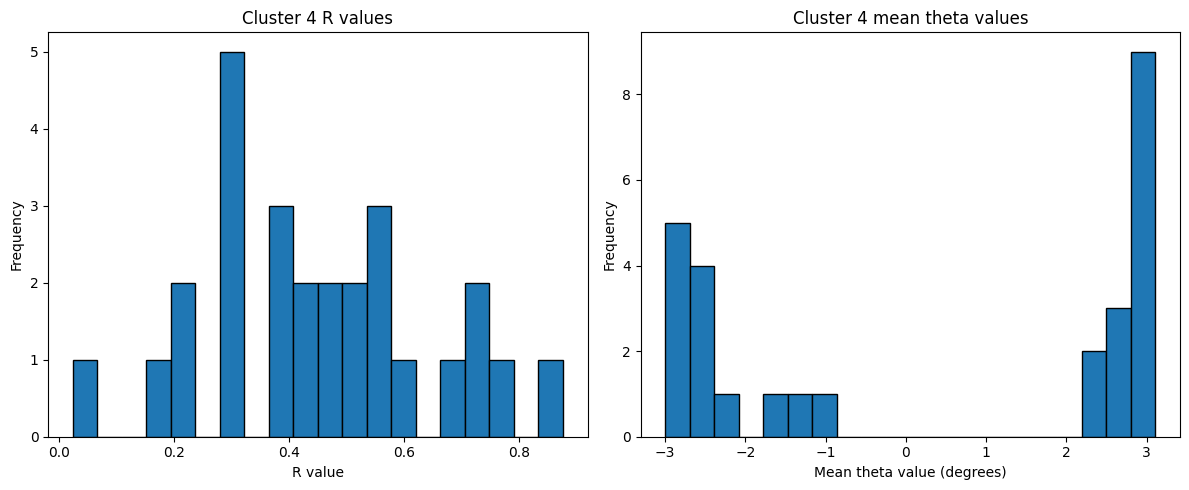

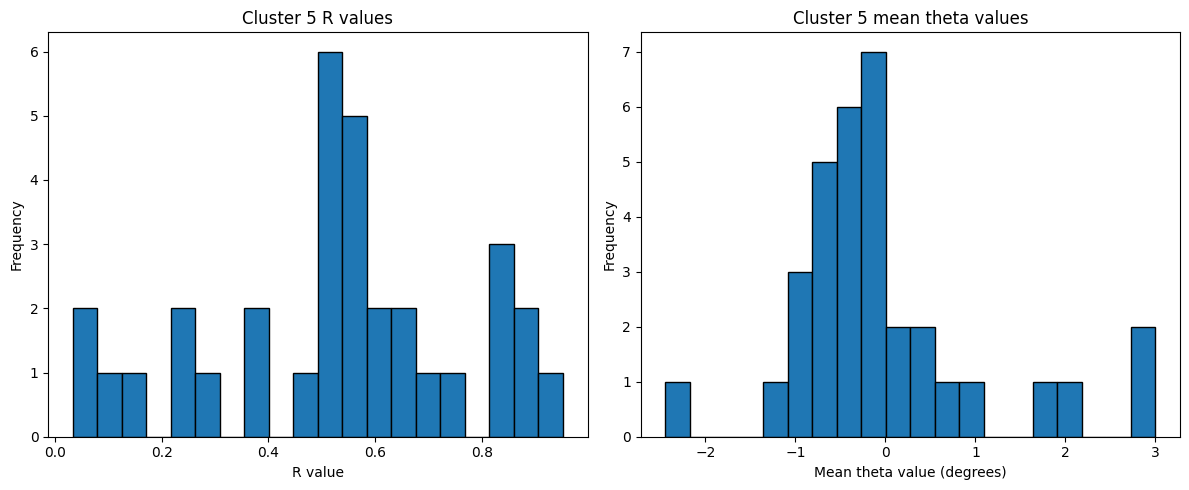

In [26]:
for i, (r, mean_theta) in enumerate(cluster_data.values(), start=1):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
        
    # Plot histogram of R values
    ax1.hist(r, bins=20, edgecolor='black')
    ax1.set_title(f"Cluster {i} R values")
    ax1.set_xlabel("R value")
    ax1.set_ylabel("Frequency")
    
    # Plot histogram of mean theta values
    ax2.hist(mean_theta, bins=20, edgecolor='black')
    ax2.set_title(f"Cluster {i} mean theta values")
    ax2.set_xlabel("Mean theta value (degrees)")
    ax2.set_ylabel("Frequency")
    
    plt.tight_layout()
    plt.show()